# Bank Term Deposit Classification

## Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.tree import plot_tree
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Metrics
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, make_scorer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from tabpfn import TabPFNClassifier

# Class imbalance
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE


## Load Data

In [ ]:
# Load the dataset
df = pd.read_csv('../data/bank_term_deposit/bank_term_deposit_prepared.csv')
df.head()

,id,split,age,job,marital,education,default,balance,housing,loan,...,day_sin,day_cos,early_month,late_month,avg_contact_duration,contacts_per_month,financial_stress,education_unknown,age_group,balance_group
0,1,labeled,31,management,married,tertiary,0,460,0,0,...,-0.571268,0.820763,0,1,0.928571,1.750,0,0,1,2
1,2,labeled,34,blue-collar,married,secondary,0,1826,1,0,...,-0.790776,-0.612106,0,1,101.500000,0.400,0,0,1,3
2,3,labeled,50,blue-collar,married,secondary,0,290,1,0,...,0.988468,0.151428,1,0,75.333333,0.375,0,0,3,2
3,4,labeled,42,admin.,divorced,secondary,0,1077,1,0,...,0.299363,-0.954139,0,0,213.000000,0.200,0,0,2,3
4,5,labeled,47,services,single,secondary,0,41,1,0,...,0.848644,0.528964,1,0,298.000000,0.200,0,0,3,2


In [7]:
df.shape

(3063, 49)

## Split Column

In [12]:
leaderboard_df = df[df['split'] == 'leaderboard'].copy()
df = df[df['split'] == 'labeled']

In [13]:
df['y'].value_counts()

y
0    1833
1     174
Name: count, dtype: int64

## Functions

In [36]:
def rs_cv_results(rs, n_best=5):
    metric_name = 'Balanced Accuracy'
    # Get the indices of the smallest Bacc values
    best_indices = np.argsort(rs.cv_results_[f'mean_test_{metric_name}'])[-n_best:]

    # Show best Baccs and their corresponding hyperparams.
    for i in best_indices[::-1]:
        print(f'{metric_name}:', rs.cv_results_[f'mean_test_{metric_name}'][i].round(2))
        print('Hyperparams:', rs.cv_results_['params'][i])
        print()

In [174]:
def create_submission(model, X, y, leaderboard_df, fts2drop, decision_th=None, fpath=''):
    X_lb = leaderboard_df.drop(columns=fts2drop)
    model.fit(X, y)
    if decision_th is None:
        preds = model.predict(X_lb)
    else:
        y_prob1 = model.predict_proba(X_lb)[:, 1]
        preds = (y_prob1 >= decision_th).astype(int)
    submission_df = pd.DataFrame({
        'id': leaderboard_df['id'],
        'prediction': preds
    })
    if not fpath:
        fpath = 'house_pricing_submission.csv'
    submission_df.to_csv(fpath, index=False)

## Preprocessing

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        # Ordinal: education has a natural order
        ('education', OrdinalEncoder(
            categories=[['unknown', 'primary', 'secondary', 'tertiary']]),
         ['education']),
        # One-hot: nominal categoricals (drop='first' to avoid collinearity)
        ('onehot', OneHotEncoder(
            drop='first', sparse_output=False, dtype=int,
            handle_unknown='ignore'),
         ['job', 'marital', 'contact', 'poutcome', 'season']),
    ],
    remainder='passthrough',  # keep all the numeric columns as-is
)

### Custom transformer for the constructed feature

Create `contact_intensity` feature. As it needs normalization, do it as a transformer so we can include it in a Pipeline and does not leak with validation or test data.

- `fit` only *learns* parameters that depend on the data &mdash; here the `MinMaxScaler` used by `contact_intensity`.
- `transform` *creates* the new columns, always working on a **copy** so the input is never mutated.

In [16]:
class ContactIntensityFeature(BaseEstimator, TransformerMixin):
    from sklearn.preprocessing import MinMaxScaler

    intensity_cols = ['campaign', 'previous', 'duration']

    def fit(self, X, y=None):
        # Learn the min/max of the contact columns from the training data only
        self.scaler_ = MinMaxScaler().fit(X[self.intensity_cols])
        return self

    def transform(self, X):
        X = X.copy()  # never mutate the caller's DataFrame

        # Contact intensity
        # Normalized so each feature contributes equally to the intensity score
        norm = self.scaler_.transform(X[self.intensity_cols])
        X['contact_intensity'] = norm.sum(axis=1)

        return X

## Train / Test

In [17]:
target_col = 'y'
fts2drop = ['id', 'split', target_col]

In [18]:
X = df.drop(columns=fts2drop)
y = df[target_col]

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

In [ ]:
cat_cols = X.select_dtypes(include='object').columns
X_train[cat_cols] = X_train[cat_cols].astype('category')
X_test[cat_cols] = X_test[cat_cols].astype('category')

## Cross-validation

In [20]:
# Declare KFold
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Declare scores to be used
scoring = {
    'Balanced Accuracy': make_scorer(balanced_accuracy_score),
    'Precision': make_scorer(precision_score, zero_division=0),
    'Recall': make_scorer(recall_score)
}

In [21]:
def print_metrics(cv_results):
    for sc in scoring.keys():
        print(f'Train {sc}:', cv_results[f'train_{sc}'].mean().round(3))
    print()
    for sc in scoring.keys():
        print(f'Validation {sc}:', cv_results[f'test_{sc}'].mean().round(3))
        
def print_metrics_rs(rand_search, idx=None):
    if idx is None:
        idx = rand_search.best_index_
    for sc in scoring.keys():
        print(f'Train {sc}:', rand_search.cv_results_[f'mean_train_{sc}'][idx].round(3))
    print()
    for sc in scoring.keys():
        print(f'Validation {sc}:', rand_search.cv_results_[f'mean_test_{sc}'][idx].round(3))

## Models

### Baseline 1

Doing something like this is not very informative...

In [23]:
from sklearn.dummy import DummyClassifier

In [24]:
bl1 = DummyClassifier(strategy='most_frequent')
bl1_cv = cross_validate(
    bl1,
    X_train,
    y_train,
    cv=kf,
    scoring=scoring,
    return_train_score=True
)

print_metrics(bl1_cv)

Train Balanced Accuracy: 0.5
Train Precision: 0.0
Train Recall: 0.0

Validation Balanced Accuracy: 0.5
Validation Precision: 0.0
Validation Recall: 0.0


In [25]:
bl1 = DummyClassifier(strategy='stratified')
bl1_cv = cross_validate(
    bl1,
    X_train,
    y_train,
    cv=kf,
    scoring=scoring,
    return_train_score=True
)

print_metrics(bl1_cv)

Train Balanced Accuracy: 0.497
Train Precision: 0.08
Train Recall: 0.079

Validation Balanced Accuracy: 0.495
Validation Precision: 0.069
Validation Recall: 0.086


### Baseline 2

In [26]:
bl2 = LogisticRegression(max_iter=10_000)
bl2_cv = cross_validate(
    bl2,
    X_train[['duration']],
    y_train,
    cv=kf,
    scoring=scoring,
    return_train_score=True
)

print_metrics(bl2_cv)

Train Balanced Accuracy: 0.712
Train Precision: 0.82
Train Recall: 0.432

Validation Balanced Accuracy: 0.712
Validation Precision: 0.821
Validation Recall: 0.433


### Logistic Regression

In [ ]:
lr_pipeline = Pipeline([
    ('contact_intensity', ContactIntensityFeature()),
    ('preprocessor', preprocessor),
    ('scaler', None),
    ('lr', LogisticRegression(
        solver='saga',
        max_iter=100_000,
    )),
])

params = [{
    'scaler': [MinMaxScaler(), RobustScaler(), StandardScaler()],
    'lr__C': np.logspace(-3, 2, 20),
    'lr__l1_ratio': np.arange(0, 1.01, 0.1),
    'lr__class_weight': [
        'balanced',
        None,
        {0:1, 1:2},
        {0:1, 1:3},
        {0:1, 1:5},
        {0:1, 1:10},
    ],
}]

lr_rs = RandomizedSearchCV(
    lr_pipeline,
    param_distributions=params,
    n_iter=50,
    scoring=scoring,
    cv=kf,
    refit='Balanced Accuracy',
    return_train_score=True,
    n_jobs=-1
)

lr_rs.fit(X_train, y_train)

print(lr_rs.best_params_)
print()
print_metrics_rs(lr_rs)

/home/ibci/.local/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/ibci/.local/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/ibci/.local/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/ibci/.local/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/ibci/.local/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/ibci/.local/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: Convergen

{'scaler': RobustScaler(), 'lr__l1_ratio': np.float64(0.4), 'lr__class_weight': {0: 1, 1: 10}, 'lr__C': np.float64(54.555947811685144)}

Train Balanced Accuracy: 0.92
Train Precision: 0.55
Train Recall: 0.91

Validation Balanced Accuracy: 0.909
Validation Precision: 0.537
Validation Recall: 0.892


In [39]:
joblib.dump(lr_rs.best_estimator_, '../models/bank/lr.joblib')

['../models/bank/lr.joblib']

## Balance

### LR experiments

In [ ]:
lr_pipeline = joblib.load('../models/bank/lr.joblib')

With random undersampling it gets a bit better in recall in exchange of a lot of precision:

In [ ]:
lr_pipeline['lr'].get_params()

{'C': np.float64(54.555947811685144),
 'class_weight': {0: 1, 1: 10},
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': np.float64(0.4),
 'max_iter': 100000,
 'n_jobs': None,
 'penalty': 'deprecated',
 'random_state': None,
 'solver': 'saga',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

In [ ]:
lr_us = ImbPipeline([
    ('rus', RandomUnderSampler()),
    ('contact_intensity', ContactIntensityFeature()),
    ('preprocessor', preprocessor),
    ('scaler', lr_pipeline['scaler']),
    ('lr', LogisticRegression(**lr_pipeline['lr'].get_params())),
])

lr_us_cv = cross_validate(
    lr_us,
    X_train,
    y_train,
    cv=kf,
    scoring=scoring,
    return_train_score=True
)

print_metrics(lr_us_cv)

Train Balanced Accuracy: 0.897
Train Precision: 0.331
Train Recall: 0.999

Validation Balanced Accuracy: 0.86
Validation Precision: 0.308
Validation Recall: 0.935


With random oversampling it gets a bit better in precision in exchange of some recall:

In [ ]:
lr_os = ImbPipeline ([
    ('ros', RandomOverSampler()),
    ('contact_intensity', ContactIntensityFeature()),
    ('preprocessor', preprocessor),
    ('scaler', lr_pipeline['scaler']),
    ('lr', LogisticRegression(**lr_pipeline['lr'].get_params())),
])

lr_os_cv = cross_validate(
    lr_os,
    X_train,
    y_train,
    cv=kf,
    scoring=scoring,
    return_train_score=True
)

print_metrics(lr_os_cv)

Train Balanced Accuracy: 0.923
Train Precision: 0.398
Train Recall: 0.998

Validation Balanced Accuracy: 0.872
Validation Precision: 0.373
Validation Recall: 0.899


Threshold study with balanced accuracy for the LR model without any under or oversampling:

In [ ]:
y_prob1 = cross_val_predict(
    lr_pipeline,
    X_train,
    y_train,
    cv=kf,
    method='predict_proba'
)[:, 1]

ths = np.arange(0, 1.05, 0.05)
baccs = []

for th in ths:
    preds = (y_prob1 > th).astype(int)
    bacc = balanced_accuracy_score(y_train, preds)
    baccs.append(bacc)

In [56]:
idx_best = np.argmax(baccs)
ths[idx_best], baccs[idx_best]

(np.float64(0.45), 0.9107908761667337)

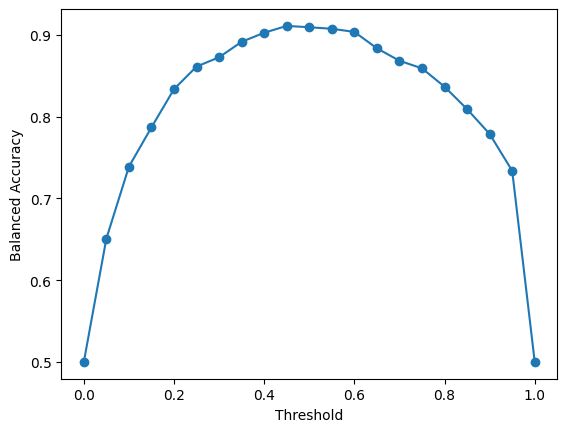

In [57]:
plt.plot(ths, baccs, marker='o')
plt.xlabel('Threshold')
plt.ylabel('Balanced Accuracy')
plt.show()

### RF experiments

Some easy experiments just to see which methods seem to work well.

In [59]:
# Standard, no class balance

rf_pipeline = Pipeline([
    ('contact_intensity', ContactIntensityFeature()),
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(max_depth=10, n_jobs=-1)),
])
     
rf_cv = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring=scoring,
    return_train_score=True
)

print_metrics(rf_cv)

Train Balanced Accuracy: 0.972
Train Precision: 1.0
Train Recall: 0.943

Validation Balanced Accuracy: 0.826
Validation Precision: 0.876
Validation Recall: 0.662


In [61]:
# Class weight

rf_pipeline = Pipeline([
    ('contact_intensity', ContactIntensityFeature()),
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(max_depth=10, class_weight='balanced', n_jobs=-1)),
])

rf_cv = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring=scoring,
    return_train_score=True
)

print_metrics(rf_cv)

Train Balanced Accuracy: 0.998
Train Precision: 0.957
Train Recall: 1.0

Validation Balanced Accuracy: 0.892
Validation Precision: 0.781
Validation Recall: 0.805


In [65]:
# Random Undersampling

rf_pipeline = ImbPipeline([
    ('rus', RandomUnderSampler()),
    ('contact_intensity', ContactIntensityFeature()),
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(max_depth=10, n_jobs=-1)),
])


rf_cv = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring=scoring,
    return_train_score=True
)

print_metrics(rf_cv)

Train Balanced Accuracy: 0.966
Train Precision: 0.587
Train Recall: 1.0

Validation Balanced Accuracy: 0.901
Validation Precision: 0.524
Validation Recall: 0.877


In [64]:
# Random Oversampling

rf_pipeline = ImbPipeline([
    ('ros', RandomOverSampler()),
    ('contact_intensity', ContactIntensityFeature()),
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(max_depth=10, n_jobs=-1)),
])

rf_cv = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring=scoring,
    return_train_score=True
)

print_metrics(rf_cv)

Train Balanced Accuracy: 0.999
Train Precision: 0.991
Train Recall: 0.999

Validation Balanced Accuracy: 0.848
Validation Precision: 0.803
Validation Recall: 0.712


In [ ]:
# SMOTE

rf_pipeline = ImbPipeline([
    ('contact_intensity', ContactIntensityFeature()),
    ('preprocessor', preprocessor),
    ('smote', SMOTE()),
    ('rf', RandomForestClassifier(max_depth=10, n_jobs=-1)),
])

rf_cv = cross_validate(
    rf_pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring=scoring,
    return_train_score=True
)

print_metrics(rf_cv)

Train Balanced Accuracy: 0.995
Train Precision: 0.992
Train Recall: 0.991

Validation Balanced Accuracy: 0.878
Validation Precision: 0.84
Validation Recall: 0.77


### RF hyperparameter tuning

For maximizing balanced accuracy, it looked like undersampling was a good strategy.

Let's try hyperparameter search with some of the best options we tried.

In [ ]:
rf_pipeline = ImbPipeline([
    ('rus', RandomUnderSampler()),
    ('contact_intensity', ContactIntensityFeature()),
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(n_jobs=-1)),
])

params = [{
    'rf__n_estimators': [100, 200, 300, 400],
    'rf__max_depth': [2, 3, 5, 10, 20, 30, 50, None],
    'rf__class_weight': [
        'balanced',
        {0: 1, 1: 2},
        {0: 1, 1: 5},
        {0: 1, 1: 10},
        {0: 1, 1: 50},
    ]
}]

rf_rs = RandomizedSearchCV(
    rf_pipeline,
    n_iter=100,
    param_distributions=params,
    scoring=scoring,
    cv=kf,
    refit='Balanced Accuracy',
    return_train_score=True,
    n_jobs=-1
)

rf_rs.fit(X_train, y_train)

print(rf_rs.best_params_)
print()
print_metrics_rs(rf_rs)

{'rf__n_estimators': 200, 'rf__max_depth': 20, 'rf__class_weight': 'balanced'}

Train Balanced Accuracy: 0.966
Train Precision: 0.583
Train Recall: 1.0

Validation Balanced Accuracy: 0.921
Validation Precision: 0.575
Validation Recall: 0.906


In [70]:
y_prob1 = cross_val_predict(
    rf_rs.best_estimator_,
    X_train,
    y_train,
    cv=kf,
    method='predict_proba'
)[:, 1]

ths = np.arange(0, 1.05, 0.05)
baccs = []

for th in ths:
    preds = (y_prob1 >= th).astype(int)
    bacc = balanced_accuracy_score(y_train, preds)
    baccs.append(bacc)

In [71]:
idx_best = np.argmax(baccs)
ths[idx_best], baccs[idx_best]

(np.float64(0.55), 0.9148517475242179)

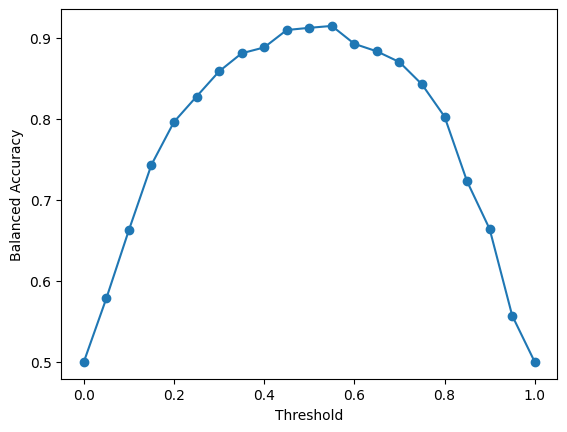

In [72]:
plt.plot(ths, baccs, marker='o')
plt.xlabel('Threshold')
plt.ylabel('Balanced Accuracy')
plt.show()

#### Feature importances

In [87]:
rf_rs.best_estimator_.fit(X_train, y_train)

# Extract the feature names from the preprocessor
feature_names = rf_rs.best_estimator_.named_steps['preprocessor'].get_feature_names_out()

rf_ft_imps = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_rs.best_estimator_['rf'].feature_importances_
}).sort_values('importance', ascending=False).round(3)

rf_ft_imps.head(20)

,feature,importance
28,remainder__duration,0.250
39,remainder__avg_contact_duration,0.150
45,remainder__contact_intensity,0.148
17,onehot__poutcome_success,0.039
34,remainder__month_cos,0.030
40,remainder__contacts_per_month,0.030
22,remainder__age,0.027
30,remainder__pdays,0.025
25,remainder__housing,0.023
32,remainder__month_num,0.023


#### Save model

In [88]:
joblib.dump(rf_rs.best_estimator_, '../models/bank/rf_ru.joblib')

['../models/bank/rf_ru.joblib']

### GB experiments

In [92]:
# Without undersampling

gb_pipeline = Pipeline([
    ('contact_intensity', ContactIntensityFeature()),
    ('gb', HistGradientBoostingClassifier(loss='log_loss', random_state=42)),
])

params = {
    'gb__learning_rate': np.logspace(-3, 0, 10),
    'gb__min_samples_leaf': [1, 2, 4, 6],
    'gb__max_depth': [3, 4, 5, 6, 8, 10, 20],
    'gb__max_features': np.arange(0.1, 1.1, 0.1),
    'gb__max_leaf_nodes': [None, 5, 10, 20],
    'gb__validation_fraction': [0.1, 0.15, 0.2],
    'gb__class_weight': [
        'balanced',
        {0: 1, 1: 2},
        {0: 1, 1: 5},
        {0: 1, 1: 10},
        {0: 1, 1: 50},
    ]
}

gb_rs = RandomizedSearchCV(
    gb_pipeline,
    n_iter=200,
    param_distributions=params,
    scoring=scoring,
    cv=kf,
    refit='Balanced Accuracy',
    return_train_score=True,
    n_jobs=-1
)

gb_rs.fit(X_train, y_train)

print(gb_rs.best_params_)
print()
print_metrics_rs(gb_rs)

{'gb__validation_fraction': 0.1, 'gb__min_samples_leaf': 4, 'gb__max_leaf_nodes': None, 'gb__max_features': np.float64(0.1), 'gb__max_depth': 3, 'gb__learning_rate': np.float64(0.004641588833612777), 'gb__class_weight': {0: 1, 1: 10}}

Train Balanced Accuracy: 0.939
Train Precision: 0.676
Train Recall: 0.919

Validation Balanced Accuracy: 0.916
Validation Precision: 0.649
Validation Recall: 0.877


In [94]:
# With understampling

gb_us_pipeline = ImbPipeline([
    ('rus', RandomUnderSampler()),
    ('contact_intensity', ContactIntensityFeature()),
    ('gb', HistGradientBoostingClassifier(loss='log_loss', random_state=42)),
])

params = {
    'gb__learning_rate': np.logspace(-3, 0, 10),
    'gb__min_samples_leaf': [1, 2, 4, 6],
    'gb__max_depth': [3, 4, 5, 6, 8, 10, 20],
    'gb__max_features': np.arange(0.1, 1.1, 0.1),
    'gb__max_leaf_nodes': [None, 5, 10, 20],
    'gb__validation_fraction': [0.1, 0.15, 0.2],
}

gb_us_rs = RandomizedSearchCV(
    gb_us_pipeline,
    n_iter=200,
    param_distributions=params,
    scoring=scoring,
    cv=kf,
    refit='Balanced Accuracy',
    return_train_score=True,
    n_jobs=-1
)

gb_us_rs.fit(X_train, y_train)

print(gb_us_rs.best_params_)
print()
print_metrics_rs(gb_us_rs)

{'gb__validation_fraction': 0.15, 'gb__min_samples_leaf': 1, 'gb__max_leaf_nodes': None, 'gb__max_features': np.float64(0.6), 'gb__max_depth': 5, 'gb__learning_rate': np.float64(0.46415888336127775)}

Train Balanced Accuracy: 0.955
Train Precision: 0.517
Train Recall: 1.0

Validation Balanced Accuracy: 0.921
Validation Precision: 0.472
Validation Recall: 0.942


#### Round 2

Works better without undersampling and just class weight.

In [95]:
rs_cv_results(gb_us_rs)

Balanced Accuracy: 0.92
Hyperparams: {'gb__validation_fraction': 0.15, 'gb__min_samples_leaf': 1, 'gb__max_leaf_nodes': None, 'gb__max_features': np.float64(0.6), 'gb__max_depth': 5, 'gb__learning_rate': np.float64(0.46415888336127775)}

Balanced Accuracy: 0.92
Hyperparams: {'gb__validation_fraction': 0.1, 'gb__min_samples_leaf': 6, 'gb__max_leaf_nodes': 20, 'gb__max_features': np.float64(0.1), 'gb__max_depth': 20, 'gb__learning_rate': np.float64(0.001)}

Balanced Accuracy: 0.92
Hyperparams: {'gb__validation_fraction': 0.1, 'gb__min_samples_leaf': 2, 'gb__max_leaf_nodes': 5, 'gb__max_features': np.float64(0.1), 'gb__max_depth': 10, 'gb__learning_rate': np.float64(0.46415888336127775)}

Balanced Accuracy: 0.92
Hyperparams: {'gb__validation_fraction': 0.1, 'gb__min_samples_leaf': 1, 'gb__max_leaf_nodes': 10, 'gb__max_features': np.float64(0.5), 'gb__max_depth': 4, 'gb__learning_rate': np.float64(0.1)}

Balanced Accuracy: 0.92
Hyperparams: {'gb__validation_fraction': 0.1, 'gb__min_samples

In [104]:
gb_us_pipeline = ImbPipeline([
    ('rus', RandomUnderSampler()),
    ('contact_intensity', ContactIntensityFeature()),
    ('gb', HistGradientBoostingClassifier(
        loss='log_loss',
        random_state=42
    )),
])

params = {
    'gb__learning_rate': np.logspace(-3, -0.3, 10),
    'gb__min_samples_leaf': [1, 2, 6],
    'gb__max_depth': [5, 10, 20],
    'gb__max_features': np.arange(0.1, 0.6, 0.05),
    'gb__max_leaf_nodes': [None, 5, 10, 20],
    'gb__validation_fraction': [0.1, 0.15],
    'gb__class_weight': [
        'balanced',
        {0: 1, 1: 50},
        {0: 1, 1: 75},
        {0: 1, 1: 100},
        {0: 1, 1: 125},
    ]
}

gb_rs = RandomizedSearchCV(
    gb_us_pipeline,
    n_iter=200,
    param_distributions=params,
    scoring=scoring,
    cv=kf,
    refit='Balanced Accuracy',
    return_train_score=True,
    n_jobs=-1
)

gb_rs.fit(X_train, y_train)

print(gb_rs.best_params_)
print()
print_metrics_rs(gb_rs)

{'gb__validation_fraction': 0.1, 'gb__min_samples_leaf': 2, 'gb__max_leaf_nodes': None, 'gb__max_features': np.float64(0.1), 'gb__max_depth': 10, 'gb__learning_rate': np.float64(0.25118864315095824), 'gb__class_weight': 'balanced'}

Train Balanced Accuracy: 0.954
Train Precision: 0.509
Train Recall: 1.0

Validation Balanced Accuracy: 0.91
Validation Precision: 0.477
Validation Recall: 0.92


In [105]:
# The previous model worked better

joblib.dump(gb_us_rs.best_estimator_, '../models/bank/gb.joblib')

['../models/bank/gb.joblib']

### XGB

In [106]:
from xgboost import XGBClassifier

In [111]:
xgb_pipeline = Pipeline([
    ('contact_intensity', ContactIntensityFeature()),
    ('xgb', XGBClassifier(n_jobs=-1)),
])

params = {
    'xgb__learning_rate': np.logspace(-2, 0, 10),
    'xgb__max_depth': [2, 3, 4, 5, 8, 10],
    'xgb__min_child_weight': [4, 6, 8, 10, 12],
    'xgb__colsample_bytree': np.arange(0.05, 0.6, 0.05),
    'xgb__max_leaves': [10, 12, 14, 15, 20],
    'xgb__subsample': np.arange(0.5, 1, 0.05),
    'xgb__scale_pos_weight': [1, 25, 50, 75, 100, 125]
}

xgb_rs = RandomizedSearchCV(
    xgb_pipeline,
    n_iter=300,
    param_distributions=params,
    scoring=scoring,
    cv=kf,
    refit='Balanced Accuracy',
    return_train_score=True,
    n_jobs=-1
)

xgb_rs.fit(X_train, y_train)

print(xgb_rs.best_params_)
print()
print_metrics_rs(xgb_rs)

{'xgb__subsample': np.float64(0.7000000000000002), 'xgb__scale_pos_weight': 75, 'xgb__min_child_weight': 12, 'xgb__max_leaves': 15, 'xgb__max_depth': 8, 'xgb__learning_rate': np.float64(0.0774263682681127), 'xgb__colsample_bytree': np.float64(0.25)}

Train Balanced Accuracy: 0.975
Train Precision: 0.651
Train Recall: 1.0

Validation Balanced Accuracy: 0.926
Validation Precision: 0.59
Validation Recall: 0.913


In [127]:
# Extract the feature names from the preprocessor
# feature_names = xgb_rs.best_estimator_.named_steps['preprocessor'].get_feature_names_out()

xgb_ft_imps = pd.DataFrame({
    'feature': X_train.columns.to_list() + ['contact_intensity'],
    'importance': xgb_rs.best_estimator_['xgb'].feature_importances_
}).sort_values('importance', ascending=False).round(3)

xgb_ft_imps.head(20)

,feature,importance
10,duration,0.083
23,avg_contact_duration,0.079
6,housing,0.078
8,contact,0.068
29,contact_intensity,0.062
25,financial_stress,0.055
1,job,0.048
14,poutcome,0.046
18,month_cos,0.044
12,pdays,0.039


In [128]:
joblib.dump(xgb_rs.best_estimator_, '../models/bank/xgb.joblib')

['../models/bank/xgb.joblib']

### Balanced RF

In [129]:
from imblearn.ensemble import BalancedRandomForestClassifier

In [131]:
brf_pipeline = Pipeline([
    ('contact_intensity', ContactIntensityFeature()),
    ('preprocessor', preprocessor),
    ('brf', BalancedRandomForestClassifier(
        replacement=True,
        random_state=42,
        n_jobs=-1
    )),
])

params = [{
    'brf__sampling_strategy': [0.1, 0.25, 0.5, 0.75, 1, 'not minority', 'all'],
    'brf__n_estimators': [100, 200, 300],
    'brf__min_samples_split': [2, 5, 10, 20],
    'brf__min_samples_leaf': [1, 2, 4, 6],
    'brf__max_depth': [5, 10, 30, 50, None],
    'brf__max_samples': [None, 0.5, 0.7, 0.9],
    'brf__max_leaf_nodes': [None, 5, 10, 20],
}]

brf_rs = RandomizedSearchCV(
    brf_pipeline,
    n_iter=200,
    param_distributions=params,
    scoring=scoring,
    cv=kf,
    refit='Balanced Accuracy',
    return_train_score=True
)

brf_rs.fit(X_train, y_train)

print(brf_rs.best_params_)
print()
print_metrics_rs(brf_rs)

{'brf__sampling_strategy': 'all', 'brf__n_estimators': 200, 'brf__min_samples_split': 5, 'brf__min_samples_leaf': 4, 'brf__max_samples': 0.9, 'brf__max_leaf_nodes': 20, 'brf__max_depth': 30}

Train Balanced Accuracy: 0.953
Train Precision: 0.641
Train Recall: 0.958

Validation Balanced Accuracy: 0.922
Validation Precision: 0.613
Validation Recall: 0.899


In [136]:
# Extract the feature names from the preprocessor
feature_names = rf_rs.best_estimator_.named_steps['preprocessor'].get_feature_names_out()

brf_ft_imps = pd.DataFrame({
    'feature': feature_names,
    'importance': brf_rs.best_estimator_['brf'].feature_importances_
}).sort_values('importance', ascending=False).round(3)

brf_ft_imps.head(20)

,feature,importance
28,remainder__duration,0.254
45,remainder__contact_intensity,0.176
39,remainder__avg_contact_duration,0.170
17,onehot__poutcome_success,0.040
34,remainder__month_cos,0.032
30,remainder__pdays,0.028
40,remainder__contacts_per_month,0.027
18,onehot__poutcome_unknown,0.023
22,remainder__age,0.021
31,remainder__previous,0.021


In [137]:
joblib.dump(brf_rs.best_estimator_, '../models/bank/brf.joblib')

['../models/bank/brf.joblib']

#### Full train study

In [142]:
brf = joblib.load('../models/bank/brf.joblib')

In [143]:
# get the probabilities for the positive class in the validation sets
y_val_probs = cross_val_predict(brf, X_train, y_train, cv=kf, method='predict_proba')
y_val_probs_1 = y_val_probs[:, 1]

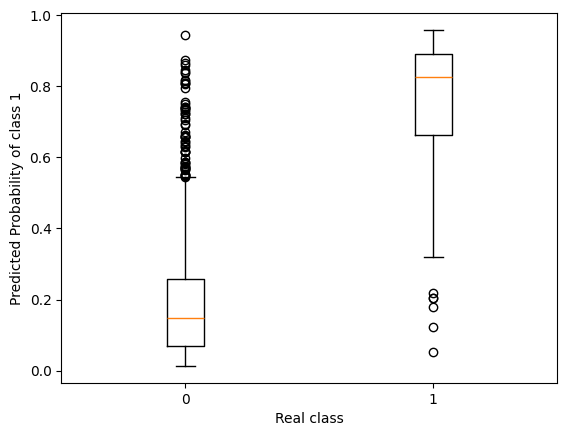

In [144]:
idx0 = np.where(y_train == 0)[0]
idx1 = np.where(y_train == 1)[0]

plt.boxplot([y_val_probs_1[idx0], y_val_probs_1[idx1]], tick_labels=[0, 1])
plt.xlabel('Real class')
plt.ylabel('Predicted Probability of class 1')
plt.show()

In [ ]:
# Vary the decision threshold and show Precision and Recall

print('Threshold | B. Acc.    | Recall    | Precision')
print('-----------------------------------------------------')
for th in list(np.arange(0, 1, 0.05)) + [0.9999]:
    bacc = balanced_accuracy_score(y_train, y_val_probs_1 > th)
    rec = recall_score(y_train, y_val_probs_1 > th)
    prec = precision_score(y_train, y_val_probs_1 > th, zero_division=0)
    print(f'{th:.2f} \t  | {prec:.3f}      | {rec:.2f}      | {bacc:.2f}')

Threshold | B. Acc.    | Recall    | Precision
-----------------------------------------------------
0.00 	  | 0.087      | 1.00      | 0.50
0.05 	  | 0.101      | 1.00      | 0.58
0.10 	  | 0.126      | 0.99      | 0.67
0.15 	  | 0.160      | 0.99      | 0.75
0.20 	  | 0.207      | 0.98      | 0.81
0.25 	  | 0.259      | 0.96      | 0.85
0.30 	  | 0.324      | 0.96      | 0.88
0.35 	  | 0.391      | 0.95      | 0.90
0.40 	  | 0.464      | 0.93      | 0.91
0.45 	  | 0.521      | 0.90      | 0.91
0.50 	  | 0.610      | 0.90      | 0.92
0.55 	  | 0.665      | 0.86      | 0.91
0.60 	  | 0.728      | 0.83      | 0.90
0.65 	  | 0.762      | 0.78      | 0.88
0.70 	  | 0.783      | 0.68      | 0.83
0.75 	  | 0.854      | 0.63      | 0.81
0.80 	  | 0.864      | 0.55      | 0.77
0.85 	  | 0.932      | 0.40      | 0.70
0.90 	  | 0.962      | 0.18      | 0.59
0.95 	  | 1.000      | 0.01      | 0.51
1.00 	  | 0.000      | 0.00      | 0.50


In [146]:
# Vary the decision on both class 1 and 0, removing data for which the model is less sure

print(f'{"Threshold":>9} | {"% Data":>7} | {"B. Acc.":>7} | {"Recall":>7} | {"Precision":>9}')
print('-' * 55)

for th in np.arange(0, 0.99, 0.05):
    y_val_ser = pd.Series(y_val_probs_1, index=y_train.index)
    likely_df = y_val_ser[(y_val_ser > th) | (y_val_ser < 1 - th)]
    likely_pred = (likely_df >= 0.5).astype(int)
    likely_y = y_train.loc[likely_df.index]

    perc_data = len(likely_df) / len(y_train)
    bacc = balanced_accuracy_score(likely_y, likely_pred)
    rec = recall_score(likely_y, likely_pred)
    prec = precision_score(likely_y, likely_pred, zero_division=0)

    print(f'{th:9.2f} | {perc_data:7.0%} | {bacc:7.3f} | {rec:7.3f} | {prec:9.3f}')

Threshold |  % Data | B. Acc. |  Recall | Precision
-------------------------------------------------------
     0.00 |    100% |   0.922 |   0.899 |     0.610
     0.05 |    100% |   0.922 |   0.899 |     0.610
     0.10 |    100% |   0.922 |   0.899 |     0.610
     0.15 |    100% |   0.922 |   0.899 |     0.610
     0.20 |    100% |   0.922 |   0.899 |     0.610
     0.25 |    100% |   0.922 |   0.899 |     0.610
     0.30 |    100% |   0.922 |   0.899 |     0.610
     0.35 |    100% |   0.922 |   0.899 |     0.610
     0.40 |    100% |   0.922 |   0.899 |     0.610
     0.45 |    100% |   0.922 |   0.899 |     0.610
     0.50 |    100% |   0.922 |   0.899 |     0.610
     0.55 |     96% |   0.926 |   0.895 |     0.665
     0.60 |     93% |   0.944 |   0.920 |     0.728
     0.65 |     88% |   0.957 |   0.940 |     0.762
     0.70 |     82% |   0.959 |   0.940 |     0.783
     0.75 |     74% |   0.961 |   0.936 |     0.854
     0.80 |     65% |   0.975 |   0.962 |     0.864
     0.8

### TabPFN

In [150]:
tabpfn_pipeline = Pipeline([
    ('contact_intensity', ContactIntensityFeature()),
    ('tabpfn', TabPFNClassifier(
        model_path='models/tabpfn_v3/tabpfn-v3-classifier-v3_20260417_binary.ckpt',
        device='cpu',
        ignore_pretraining_limits=True,   # to allow running on more than 1000 rows with cpu
        n_jobs=-1,
    )),
])

# Perform cross-validation (no need of hyperparameter tuning)
tabpfn_cv = cross_validate(
    tabpfn_pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

print_metrics(tabpfn_cv)

Train Balanced Accuracy: 0.986
Train Precision: 0.992
Train Recall: 0.973

Validation Balanced Accuracy: 0.882
Validation Precision: 0.85
Validation Recall: 0.777


In [151]:
# get the probabilities for the positive class in the validation sets
y_val_probs = cross_val_predict(tabpfn_pipeline, X_train, y_train, cv=kf, method='predict_proba')
y_val_probs_1 = y_val_probs[:, 1]

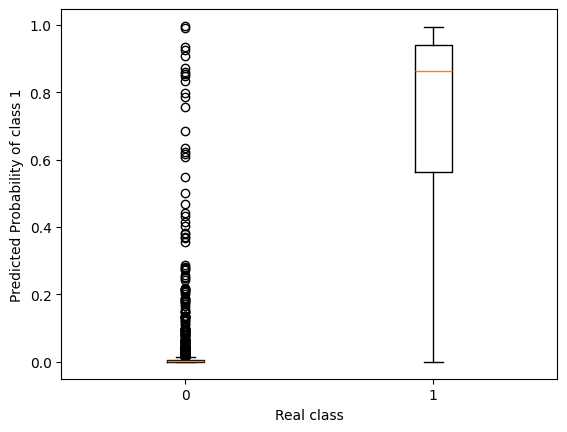

In [152]:
idx0 = np.where(y_train == 0)[0]
idx1 = np.where(y_train == 1)[0]

plt.boxplot([y_val_probs_1[idx0], y_val_probs_1[idx1]], tick_labels=[0, 1])
plt.xlabel('Real class')
plt.ylabel('Predicted Probability of class 1')
plt.show()

By varying the decision threshold, it achieves a good balanced accuracy!

In [153]:
# Vary the decision threshold and show Precision and Recall

print('Threshold | B. Acc.    | Recall    | Precision')
print('-----------------------------------------------------')
for th in list(np.arange(0, 1, 0.05)) + [0.9999]:
    bacc = balanced_accuracy_score(y_train, y_val_probs_1 > th)
    rec = recall_score(y_train, y_val_probs_1 > th)
    prec = precision_score(y_train, y_val_probs_1 > th, zero_division=0)
    print(f'{th:.2f} \t  | {prec:.3f}      | {rec:.2f}      | {bacc:.2f}')

Threshold | B. Acc.    | Recall    | Precision
-----------------------------------------------------
0.00 	  | 0.087      | 1.00      | 0.50
0.05 	  | 0.530      | 0.94      | 0.93
0.10 	  | 0.635      | 0.93      | 0.94
0.15 	  | 0.678      | 0.88      | 0.92
0.20 	  | 0.717      | 0.86      | 0.91
0.25 	  | 0.756      | 0.85      | 0.91
0.30 	  | 0.789      | 0.81      | 0.89
0.35 	  | 0.789      | 0.81      | 0.89
0.40 	  | 0.816      | 0.80      | 0.89
0.45 	  | 0.840      | 0.79      | 0.89
0.50 	  | 0.844      | 0.78      | 0.88
0.55 	  | 0.855      | 0.76      | 0.88
0.60 	  | 0.850      | 0.73      | 0.86
0.65 	  | 0.874      | 0.70      | 0.84
0.70 	  | 0.880      | 0.68      | 0.84
0.75 	  | 0.875      | 0.65      | 0.82
0.80 	  | 0.895      | 0.61      | 0.80
0.85 	  | 0.901      | 0.53      | 0.76
0.90 	  | 0.917      | 0.40      | 0.70
0.95 	  | 0.935      | 0.21      | 0.60
1.00 	  | 0.000      | 0.00      | 0.50


In [154]:
joblib.dump(tabpfn_pipeline, '../models/bank/tabpfn.joblib')

['../models/bank/tabpfn.joblib']

## Test

In [155]:
models = {
    'LR': joblib.load('../models/bank/lr.joblib'),
    'RF': joblib.load('../models/bank/rf_ru.joblib'),
    'GB': joblib.load('../models/bank/gb.joblib'),
    'XGB': joblib.load('../models/bank/xgb.joblib'),
    'BRF': joblib.load('../models/bank/brf.joblib'),
    'TabPFN': joblib.load('../models/bank/tabpfn.joblib'),
}

Based on validation balanced accuracy, search for the best decision threshold for each model.

In [ ]:
thresholds = np.arange(0, 1.01, 0.01)

best_thresholds = {}
test_bal_accs = {}

for name, model in models.items():
    print(name)

    # Validation preds via CV
    val_probs1 = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=kf,
        method="predict_proba"
    )[:, 1]

    # Scan thresholds
    best_bacc = -1
    best_th = None

    for th in thresholds:
        preds = (val_probs1 >= th).astype(int)
        bacc = balanced_accuracy_score(y_train, preds)
        if bacc > best_bacc:
            best_bacc = bacc
            best_th = th

    best_thresholds[name] = best_th

    # Retrain model fully
    model.fit(X_train, y_train)

    # Evaluate on test using chosen threshold
    test_probs = model.predict_proba(X_test)[:, 1]
    test_preds = (test_probs >= best_th).astype(int)

    test_bacc = balanced_accuracy_score(y_test, test_preds)
    test_bal_accs[name] = test_bacc

LR
RF
GB
XGB
BRF
TabPFN


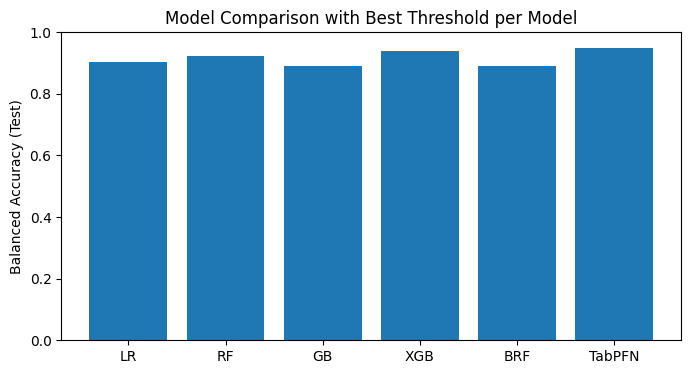

In [159]:
plt.figure(figsize=(8, 4))
plt.bar(test_bal_accs.keys(), test_bal_accs.values())
plt.ylabel("Balanced Accuracy (Test)")
plt.title("Model Comparison with Best Threshold per Model")
plt.ylim(0, 1)
plt.show()

In [160]:
test_bal_accs

{'LR': 0.9026469443363176,
 'RF': 0.9237446477228494,
 'GB': 0.8890229661346827,
 'XGB': 0.939392759828727,
 'BRF': 0.8890618917866875,
 'TabPFN': 0.947567146749708}

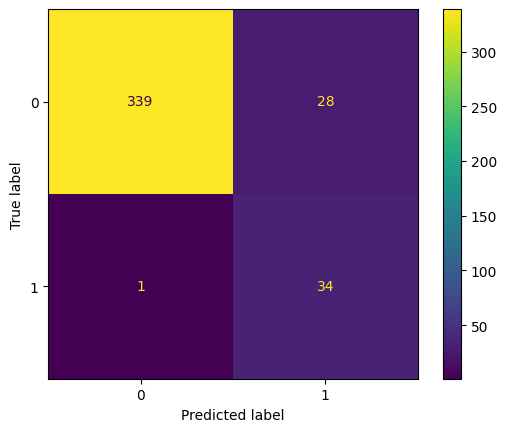

In [162]:
best_th = best_thresholds['TabPFN']

test_probs = models['TabPFN'].predict_proba(X_test)[:, 1]
test_preds = (test_probs >= best_th).astype(int)

cm = confusion_matrix(y_test, test_preds, labels=[0, 1])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)
disp.plot()
plt.show()

## Submission

In [ ]:
thresholds = np.arange(0, 1.01, 0.01)

# Validation preds via CV
probs1 = cross_val_predict(
    models['TabPFN'],
    X,
    y,
    cv=kf,
    method="predict_proba"
)[:, 1]
    
# Scan thresholds
best_bacc = -1
best_th = None

for th in thresholds:
    preds = (probs1 >= th).astype(int)
    bacc = balanced_accuracy_score(y, preds)
    if bacc > best_bacc:
        best_bacc = bacc
        best_th = th


print('Best B. Acc.:', round(best_bacc, 3))
print('Best threshold:', best_th)

In [ ]:
# The function trains with the whole dataset

create_submission(
    models['TabPFN'],
    X,
    y,
    leaderboard_df,
    fts2drop,
    decision_th=best_th,
    fpath='../data/bank_term_deposit/tabpfn_bank_submission.csv'
)